# Bank Customer Churn — Classification with Neural Network

**Workflow:** EDA → Cleaning → Encoding → Scaling → Train/Test Split → Neural Network → Model Comparison → Evaluation → Visualizations.

The original notebook reached about **86% accuracy**. This version keeps the same scope, improves the organization, fixes preprocessing leakage, and makes a lightweight attempt at improving the result toward 90%.

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Basic EDA

In [3]:
print("Dataset shape:", df.shape)
df.info()
display(df.describe())

Dataset shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
print("Target distribution:")
print(df["Exited"].value_counts())
print("\nTarget distribution (%):")
print((df["Exited"].value_counts(normalize=True) * 100).round(2))

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Target distribution (%):
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


### Target Distribution
`Exited = 0` means the customer stayed, while `Exited = 1` means the customer left.

The classes are imbalanced, so accuracy will be accompanied by a confusion matrix and classification report.

In [5]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


In [6]:
print("Geography:")
print(df["Geography"].value_counts())
print("\nGender:")
print(df["Gender"].value_counts())
print("\nUnique values:")
print(df.nunique())

Geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Unique values:
RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64


In [7]:
print("HasCrCard:")
print(df["HasCrCard"].value_counts())
print("\nIsActiveMember:")
print(df["IsActiveMember"].value_counts())
print("\nNumOfProducts:")
print(df["NumOfProducts"].value_counts())

HasCrCard:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

NumOfProducts:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


## 3. EDA Visualizations

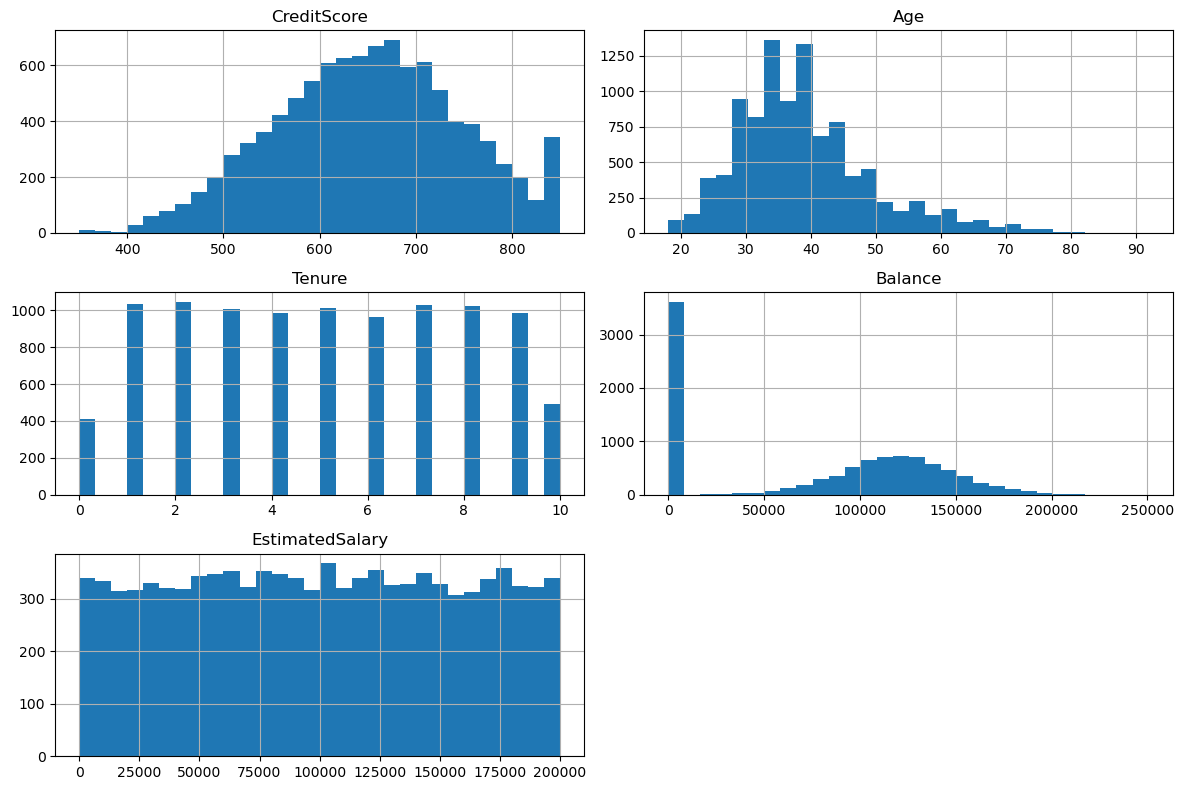

In [8]:
df[["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]].hist(
    figsize=(12, 8), bins=30
)
plt.tight_layout()
plt.show()

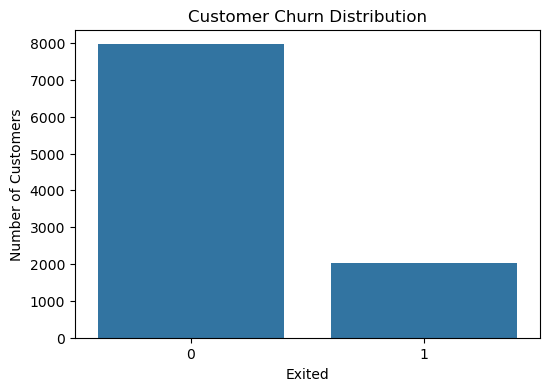

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Exited")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

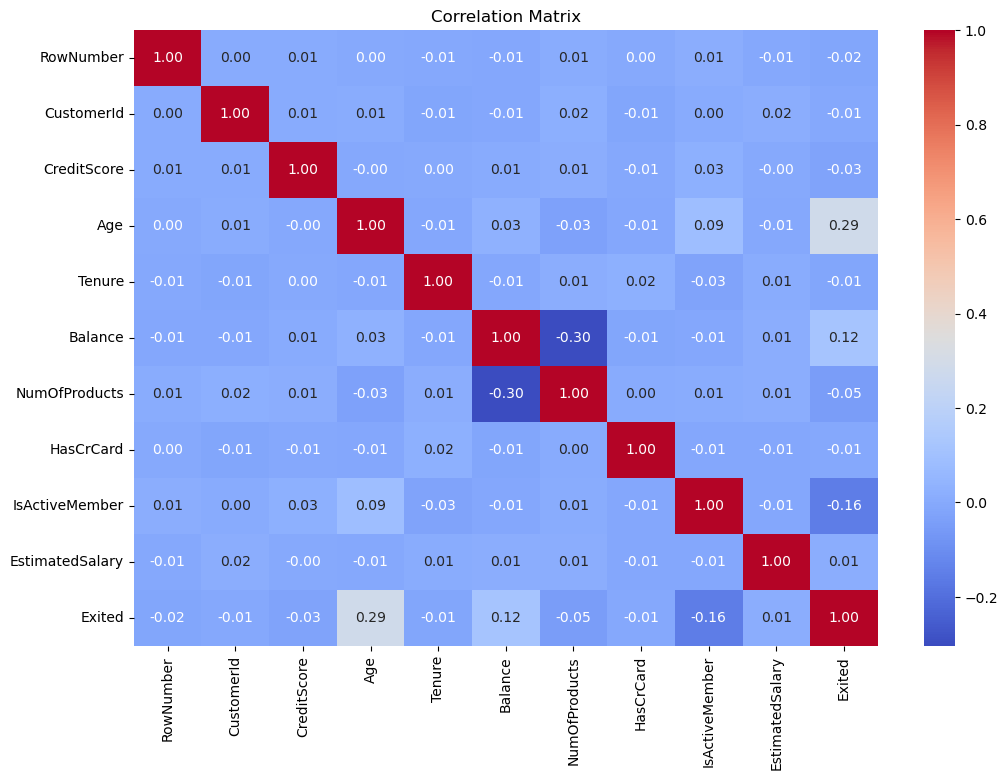

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [11]:
print("Exit rate by Geography (%):")
display(pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100)

print("Exit rate by Gender (%):")
display(pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100)

Exit rate by Geography (%):


Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


Exit rate by Gender (%):


Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


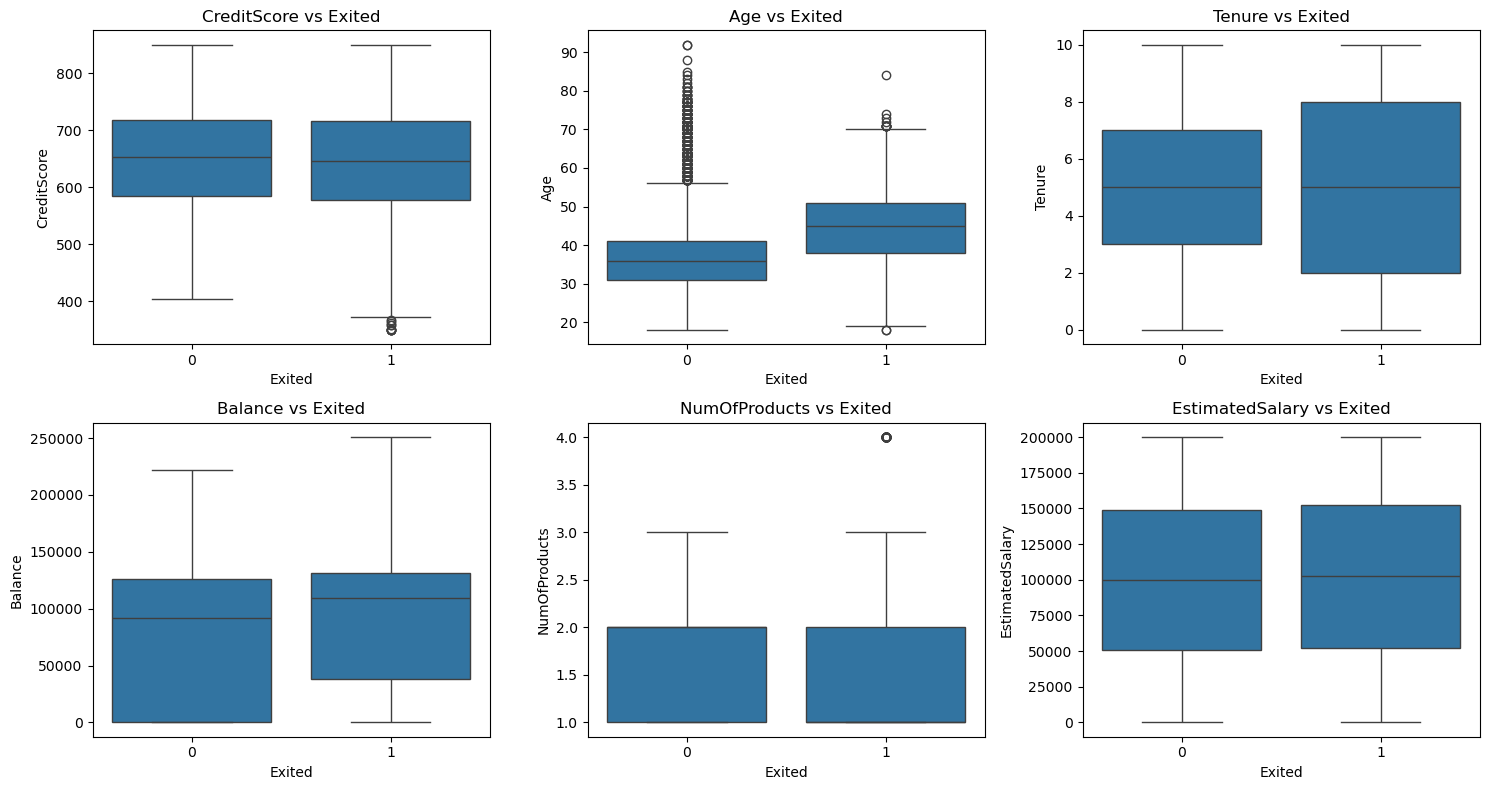

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]

for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x="Exited", y=feature, ax=ax)
    ax.set_title(f"{feature} vs Exited")

plt.tight_layout()
plt.show()

## 4. Cleaning and Preprocessing

The original analysis found no important missing-value problem and no duplicate-row problem. We therefore keep cleaning focused:

- remove identifiers;
- encode categorical features;
- convert boolean dummy columns to integers.

In [13]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True
)

bool_columns = df.select_dtypes(include="bool").columns
df[bool_columns] = df[bool_columns].astype(int)

print("Shape after preprocessing:", df.shape)
display(df.head())

Shape after preprocessing: (10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


## 5. Features and Target

In [14]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


## 6. Train/Test Split and Scaling

The important correction here is that the scaler is **fitted only on the training data**. The test set is transformed afterward. This avoids information leakage.

`stratify=y` also keeps the class proportions similar in train and test.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1,
    stratify=y
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


## 7. Model 1 — Baseline

In [16]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

print("Best Validation Accuracy:", max(history.history["val_accuracy"]))

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7933 - loss: 0.4951 - val_accuracy: 0.7912 - val_loss: 0.4716
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8019 - loss: 0.4522 - val_accuracy: 0.8012 - val_loss: 0.4576
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8084 - loss: 0.4369 - val_accuracy: 0.8062 - val_loss: 0.4403
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8197 - loss: 0.4135 - val_accuracy: 0.8331 - val_loss: 0.4124
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8327 - loss: 0.3897 - val_accuracy: 0.8425 - val_loss: 0.3879
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8380 - loss: 0.3736 - val_accuracy: 0.8425 - val_loss: 0.3843
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8467 - loss: 0.3647 - val_accuracy: 0.8506 - val_loss: 0.3723
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8509 - loss: 0.3579 - val_accuracy: 0.

## 8. Model 2 — Moderate Improvement

In [19]:
model_2 = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

history_2 = model_2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=callbacks,
    verbose=1
)

print("Best Validation Accuracy:", max(history_2.history["val_accuracy"]))

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7834 - loss: 0.4887 - val_accuracy: 0.8006 - val_loss: 0.4597 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8127 - loss: 0.4354 - val_accuracy: 0.8181 - val_loss: 0.4350 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8236 - loss: 0.4136 - val_accuracy: 0.8300 - val_loss: 0.4223 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8320 - loss: 0.3937 - val_accuracy: 0.8394 - val_loss: 0.3826 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8428 - loss: 0.3711 - val_accuracy: 0.8462 - val_loss: 0.3677 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8534 - loss: 0.3593 - val_accuracy: 0.8506 - val_loss: 0.3584 - learning_rate: 0.0010
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8539 - loss: 0.

## 9. Model 3 — Batch Size Experiment

In [20]:
model_3 = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.20,
    callbacks=callbacks,
    verbose=1
)

print("Best Validation Accuracy:", max(history_3.history["val_accuracy"]))

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7977 - loss: 0.4940 - val_accuracy: 0.7906 - val_loss: 0.4727 - learning_rate: 0.0010
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8005 - loss: 0.4560 - val_accuracy: 0.7975 - val_loss: 0.4636 - learning_rate: 0.0010
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8081 - loss: 0.4458 - val_accuracy: 0.8056 - val_loss: 0.4514 - learning_rate: 0.0010
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8155 - loss: 0.4350 - val_accuracy: 0.8094 - val_loss: 0.4420 - learning_rate: 0.0010
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8163 - loss: 0.4267 - val_accuracy: 0.8194 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8170 - loss: 0.4171 - val_accuracy: 0.8194 - val_loss: 0.4213 - learning_rate: 0.0010
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8247 - loss: 0.

## 10. Compare Models

In [21]:
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Best Validation Accuracy": [
        max(history.history["val_accuracy"]),
        max(history_2.history["val_accuracy"]),
        max(history_3.history["val_accuracy"])
    ]
})

results["Best Validation Accuracy"] = (results["Best Validation Accuracy"] * 100).round(2)
display(results)

,Model,Best Validation Accuracy
0,Model 1,86.50
1,Model 2,86.37
2,Model 3,86.94


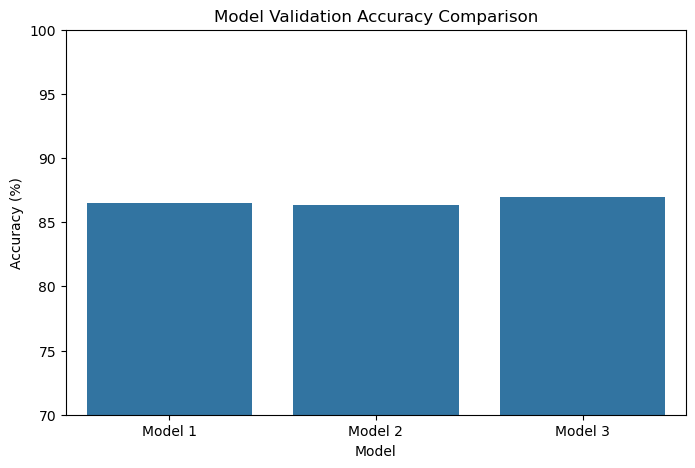

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="Best Validation Accuracy")
plt.ylim(70, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Validation Accuracy Comparison")
plt.show()

## 11. Select the Best Model and Plot Training Curves

In [23]:
histories = {"Model 1": history, "Model 2": history_2, "Model 3": history_3}
models = {"Model 1": model, "Model 2": model_2, "Model 3": model_3}

best_model_name = results.loc[results["Best Validation Accuracy"].idxmax(), "Model"]
best_model = models[best_model_name]
best_history = histories[best_model_name]

print("Selected model:", best_model_name)

Selected model: Model 3


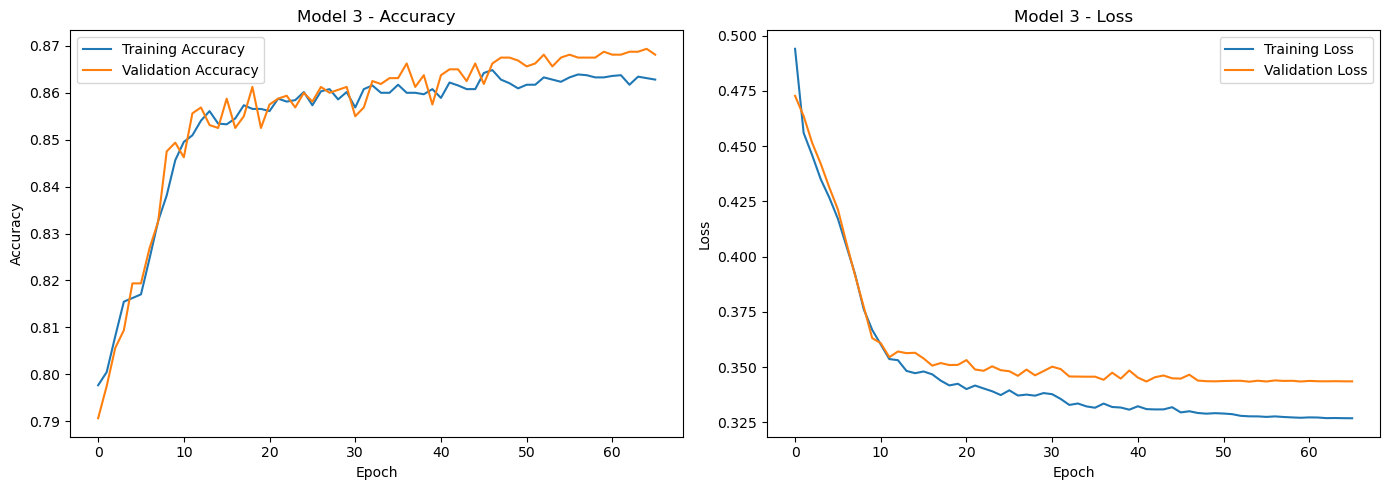

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(best_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title(f"{best_model_name} - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Training Loss")
axes[1].plot(best_history.history["val_loss"], label="Validation Loss")
axes[1].set_title(f"{best_model_name} - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Final Test Evaluation

In [25]:
test_loss, test_accuracy = best_model.evaluate(X_test_scaled, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8520 - loss: 0.3552   
Test Loss: 0.355170875787735
Test Accuracy: 0.8519999980926514
Test Accuracy: 85.20%


In [26]:
y_pred_prob = best_model.predict(X_test_scaled)
y_pred_class = (y_pred_prob >= 0.5).astype(int).ravel()

print(classification_report(
    y_test,
    y_pred_class,
    target_names=["Stayed", "Exited"]
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
              precision    recall  f1-score   support

      Stayed       0.87      0.95      0.91      1593
      Exited       0.71      0.46      0.56       407

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.73      2000
weighted avg       0.84      0.85      0.84      2000



## 13. Confusion Matrix

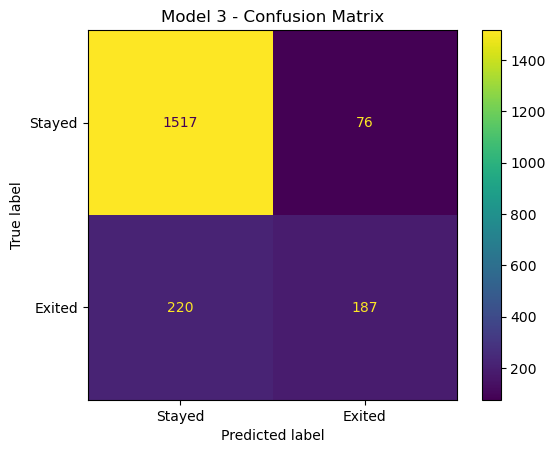

In [27]:
cm = confusion_matrix(y_test, y_pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Exited"]
)

disp.plot()
plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

## 14. Final Conclusion

The final score is reported on the untouched test set.

**Accuracy is not the only metric:** because the target is imbalanced, the confusion matrix and classification report are also important.

The original ~86% result is already a solid result. The additional experiments here try to improve it without turning the assignment into a large feature-engineering project. If the test accuracy reaches 90% while remaining stable, we keep it; otherwise, we keep the best honest result rather than forcing the number higher.